In [4]:
from anndata import AnnData
import tifffile
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.io
from tqdm import tqdm
import pandas as pd

In [5]:
# loading the data
filepath = "/Volumes/Intenso/spatial-transcriptomics/"

dapi = tifffile.imread(filepath+"A1_DAPI.tiff")

column_names = ["spot_location_1", "spot_location_2", "spot_location_3", "gene_name"]
spots = pd.read_csv(filepath+"A1_results.txt", delimiter="\t", usecols=[0,1,2,3], header = None, names=column_names)


In [6]:
spots.head(10)

,spot_location_1,spot_location_2,spot_location_3,gene_name
0,9,16,16,Slc3a2
1,63,416,17,Slc3a2
2,187,105,17,Slc3a2
3,24,539,18,Slc3a2
4,37,484,18,Slc3a2
5,38,102,18,Slc3a2
6,59,442,18,Slc3a2
7,62,652,18,Slc3a2
8,87,172,18,Slc3a2
9,97,457,18,Slc3a2


In [7]:
### convert gene_name to gene identity
genes=pd.DataFrame(spots['gene_name'].unique())
a1=list(genes[0])
gene=list(map(lambda x: a1.index(x)+1, spots['gene_name']))
spots['gene']=gene
spots['gene']=spots['gene'].astype('int')

# ### save gene annotation as genelist.csv
genes.to_csv(filepath+'clustermap_genelist.csv', header=False, index=False)

Text(0.5, 1.0, 'raw data')

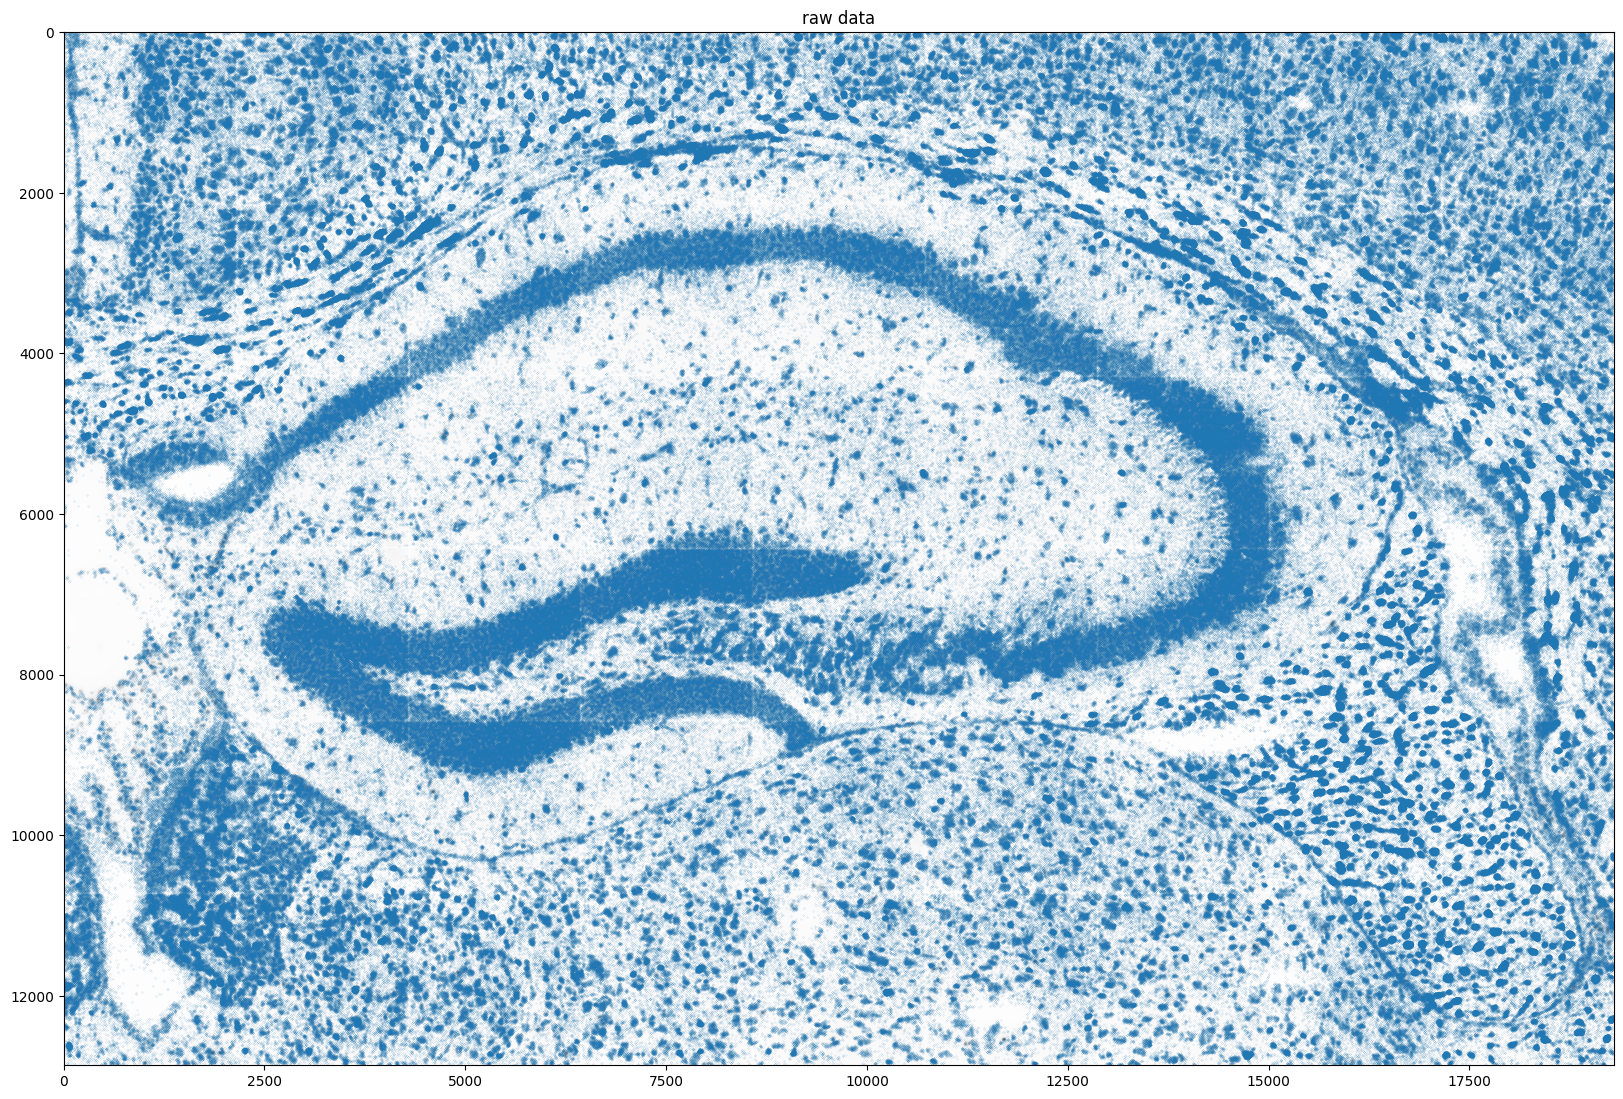

In [8]:
# overview
plt.figure(figsize=(20,20))
length=1000
plt.imshow(dapi,cmap='Greys')
plt.scatter(spots['spot_location_1'],spots['spot_location_2'],s=0.005)
plt.title('raw data')

In [ ]:
### set radius parameters
xy_radius=35

In [ ]:
num_gene=np.max(spots['gene'])

gene_list=np.arange(1,num_gene+1)
num_dims=len(dapi.shape)
model = ClusterMap(spots=spots, dapi=dapi, gene_list=gene_list, num_dims=num_dims,
                   xy_radius=xy_radius,z_radius=0,fast_preprocess=True)

In [ ]:
### trim
img = dapi
window_size=1500
label_img = get_img(img, spots, window_size=window_size, margin=math.ceil(window_size*0.1))
out = split(img, label_img, spots, window_size=window_size, margin=math.ceil(window_size*0.1))

In [ ]:
###plot a tile
tile_num=80
plt.figure(figsize=(8,8))
plt.imshow(out.loc[tile_num,'img'],cmap='Greys')

plt.scatter(out.loc[tile_num,'spots']['spot_location_1'],
            out.loc[tile_num,'spots']['spot_location_2'],s=0.1)
plt.title(f'splitted tile: {tile_num}')

In [ ]:
%%time

### process each tile
pct_filter=0
model.spots['clustermap']=-1

for tile_num in range(out.shape[0]):
    print(f'tile: {tile_num}')
    spots_tile=out.loc[tile_num,'spots']
    dapi_tile=out.loc[tile_num,'img']

    ### instantiate model
    model_tile = ClusterMap(spots=spots_tile, dapi=dapi_tile, gene_list=gene_list, num_dims=num_dims,
                   xy_radius=xy_radius,z_radius=0,fast_preprocess=False)

    ###preprocessing
    model_tile.preprocess(dapi_grid_interval=3,pct_filter=pct_filter)

    # ### segmentation
    model_tile.min_spot_per_cell=5
    model_tile.segmentation(cell_num_threshold=0.1,dapi_grid_interval=3,add_dapi=True,use_genedis=True)

    # ### plot cell segmentation results in spots (colored by cells)
    model_tile.plot_segmentation(figsize=(4,4),s=0.01,plot_with_dapi=True,plot_dapi=True, show=False)

    # ### stitch tiles together
    model.stitch(model_tile,out,tile_num)
    model.plot_segmentation(figsize=(30,15),s=0.05,plot_with_dapi=False,plot_dapi=True, show=False)
    plt.show()

In [ ]:
model.plot_segmentation(figsize=(30,15),s=0.05,plot_with_dapi=False,plot_dapi=True, show=False)
plt.scatter(model.cellcenter_unique[:,1],model.cellcenter_unique[:,0],c='r',s=20)
plt.show()

In [ ]:
path_save = filepath+'A1_spots_all.csv'
model.save_segmentation(path_save)

In [ ]:
model.create_convex_hulls()

In [ ]:
import alphashape
import geopandas as gpd
import spatialdata as sd
from spatialdata import SpatialData
import anndata as ad
import xarray as xr

In [ ]:
# Reading in A1 spots that was created with ClusterMap
spots_df = pd.read_csv(filepath+'A1_spots_all.csv')

spots_df = spots_df.rename(columns={'clustermap': 'cell_id'}) # renaming the column from clustermap to cell_id

# Create a list to hold cell data
cell_data = []
cell_ids = []

spots_df

In [ ]:
unique_cell_ids = spots_df[spots_df['cell_id'] > -1]['cell_id'].unique()

In [ ]:
print(len(unique_cell_ids))
unique_cell_ids

In [ ]:
def alphashape_poly_generate(molecules, x_label="x", y_label="y", alpha=0.05):
    points = np.array([molecules[x_label], molecules[y_label]]).T
    poly = alphashape.alphashape(points, alpha).buffer(0)
    # Get rid of weird self-intersections
    poly = poly.buffer(5).buffer(-5).buffer(0)
    return poly

In [ ]:
print("Converting clustermap results to alphashape polygons") # making the segmentations, ClusterMap assigned each spot to a cell but did not do the segmentations.
for cell_id in unique_cell_ids:
    # Filter spots belonging to this cell
    df = spots_df[spots_df['cell_id'] == cell_id]
    
    # Skip if too few points
    if len(df) < 3:
        continue
        
    # Generate the polygon
    try:
        cell_poly = alphashape_poly_generate(
            df, x_label="spot_location_1", y_label="spot_location_2", alpha=0.05
        )
        cell_data.append(cell_poly)
        cell_ids.append(cell_id)
    except Exception as e:
        print(f"Error processing cell {cell_id}: {e}")

In [ ]:
# Create a GeoDataFrame with cell IDs
cells_gdf = gpd.GeoDataFrame({
    'cell_id': cell_ids,
    'geometry': cell_data
})
cells_gdf

In [ ]:
# save the cells_gdf
gdf_path_save = filepath+'A1_cell_polygons.csv'
cells_gdf.to_csv(gdf_path_save)

In [ ]:
from shapely.geometry import Polygon, Point

# Now let's create point geometries for each spot. This converts the tabular data into a GeoDataframe where each gene detected spot as geometric information.
spots_geometry = [Point(row['spot_location_1'], row['spot_location_2']) for _, row in spots_df.iterrows()]
spots_gdf = gpd.GeoDataFrame(
    spots_df.copy(),
    geometry=spots_geometry
)

In [ ]:
# Create cell-level data (aggregating gene counts by cell)
# Group spots by clustermap ID and count genes
cell_gene_counts = spots_df.groupby(['cell_id', 'gene_name']).size().reset_index(name='count')

# Pivot to get a gene x cell matrix
gene_count_matrix = cell_gene_counts.pivot(
    index='cell_id', 
    columns='gene_name', 
    values='count'
).fillna(0)

In [ ]:
gene_count_matrix.shape

In [ ]:
# Parsing the DAPI image

from spatialdata.models import Image2DModel

# Assuming dapi is your loaded DAPI image array with shape (height, width)
# Add a channel dimension
dapi_with_channel = dapi[np.newaxis, :, :]  # Shape becomes (1, height, width)

# Now parse the data
parsed_image = Image2DModel.parse(dapi_with_channel)

# Should now pass validation
Image2DModel().validate(parsed_image)

# parsed_image is a regular xarray.DataArray object (discussed later), and as such it can be used outside
# the SpatialData library (e.g. with the libraries dask-image, xarray-spatial, ...)
parsed_image

In [ ]:
# Parsing the points

from spatialdata.models import PointsModel

# Define dtypes explicitly
dtypes = {
    "spot_location_1": float,
    "spot_location_2": float,
    "spot_location_3": float,
    "gene_name": 'category',
    "gene": "category",
    "cell_id": "category",   
}

spots_df = pd.read_csv("/Volumes/KINGSTON/data/phd/spatial-transcriptomics/A1_spots_all.csv", dtype=dtypes)
parsed_points = PointsModel.parse(spots_df, coordinates={"x": "spot_location_1", "y": "spot_location_2"})


In [ ]:
# Parsing the shapes (polygons)

import geopandas as gdp
from spatialdata.models import ShapesModel
from shapely.wkt import loads

polygons_df = pd.read_csv("/Volumes/KINGSTON/data/phd/spatial-transcriptomics/A1_cell_polygons.csv")

# convert the geomtry from WKT strings to shapely geometries
polygons_df['geometry'] = polygons_df['geometry'].apply(loads)

gdf = gdp.GeoDataFrame(polygons_df, geometry="geometry")
gdf_cell_id_index = gdf.set_index("cell_id")
parsed_polygons = ShapesModel.parse(gdf_cell_id_index)
gdf_cell_id_index

In [ ]:
# Parsing the Tables (gene x count matrix)

from spatialdata.models import TableModel

# Create AnnData object for gene expression
table = ad.AnnData(
    X=gene_count_matrix.values,
    obs=pd.DataFrame(index=gene_count_matrix.index),
    var=pd.DataFrame(index=gene_count_matrix.columns)
)

parsed_table = TableModel.parse(table)

In [ ]:
# checking my spatialData object

my_sdata = SpatialData(
    images = {"A1_dapi": parsed_image}, 
    points = {"A1_points": parsed_points},
    shapes = {"A1_polygons": parsed_polygons},
    tables = {"A1_table": parsed_table})
my_sdata

In [ ]:
my_sdata["A1_table"]

In [ ]:
my_sdata.pl.render_shapes(element="A1_polygons", color="cell_id", cmap="rainbow", method="datashader").pl.show()

In [ ]:
my_sdata.pl.render_points(element="A1_points", color="gene_name", cmap="rainbow", size = 0.01).pl.show()

In [ ]:
my_sdata["A1_points"].compute()

In [ ]:
astrocytic_genes = ["Fam171a2"]
astrocytic_genes

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 10]

# Then run your original plotting command
my_sdata.pl.render_points(color="gene_name", groups=astrocytic_genes, scale="full", cmap="viridis").pl.render_shapes(
    "A1_polygons", fill_alpha=0.6, method="datashader", color="back"
).pl.show()

In [ ]:
my_sdata_shapes = my_sdata.aggregate(values="A1_points", by="A1_polygons", value_key="gene_name", agg_func="count")
my_sdata_shapes

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 10]

ax = plt.gca()
my_sdata.pl.render_points(color="gene_name", groups="Hepacam").pl.show(ax=ax)
my_sdata_shapes.pl.render_shapes(color="Gfap", cmap="viridis", fill_alpha=0.7, method="datashader").pl.show(ax=ax)

In [ ]:
import squidpy as sq

In [ ]:
import scanpy as sc
from matplotlib.pyplot import rc_context

In [ ]:
sc.pp.normalize_total(my_sdata["A1_table"])
sc.pp.log1p(my_sdata["A1_table"])
sc.pp.pca(my_sdata["A1_table"])
sc.pp.neighbors(my_sdata["A1_table"])
sc.tl.umap(my_sdata["A1_table"])
sc.tl.leiden(my_sdata["A1_table"],
           flavor="igraph", 
           n_iterations=2,
           resolution=1,
           key_added="clusters")

In [ ]:
my_sdata["A1_table"].obs

In [ ]:
with rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(
        my_sdata["A1_table"],
        color="clusters",
        add_outline=True,
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=True,
        title="clustering of cells",
        palette="tab10",
    )

In [ ]:
marker_genes_dict = {
    "Neurons": ["Rbfox3", "Syt1", "Snap25"],
    "Excitatory Neurons": ["Slc17a7", "Slc17a6"],
    "inhibitory Neurons": ["Gad1", "Gad2"],
    "Astrocytes": ["Aldh1l1", "Aqp4", "Slc1a3", "Slc1a2", "Aldoc"],
    "Endothelial cells": ["Pecam1", "Flt1"],
    "Oligodendrocytes": ["Mog", "Plp1"],
    "Microglia": ["Csf1r", "C1qa"],
    "OPCs": ["Tnr", "Vcan"]
}

In [ ]:
sc.pl.dotplot(my_sdata["A1_table"], marker_genes_dict, "clusters", dendrogram=True, cmap="seismic", vmin=0, vcenter=0.75, vmax=1.5,log=False)

In [ ]:
#TODO: need to annotate the clusters back into the spatialdata object. And then use the my_sdata.pl.render_shapes() function
# For this, I need to join the my_sdata["A1_polygons"] with my_sdata["A1_table"].obs. However, when doing the merge, it does not work. The nr of rows are not the same but the ranking shows that there must be a match.

# It is probably the type of the index values. Object vs Int64 type. Resparse the my_sdata["A1_table"] such that it is a int64.

print(my_sdata["A1_polygons"].shape)
my_sdata["A1_polygons"]

In [ ]:
my_sdata["A1_table"].obs.index

In [ ]:
my_sdata["A1_polygons"].index

In [ ]:
# Ranking the indexes

# Convert cell_id to integers and rank them in my_sdata["A1_table"].obs
table_cell_ids = pd.to_numeric(my_sdata["A1_table"].obs.index, errors='coerce').dropna().astype('int64').sort_values()

# Ranking cell_id in my_sdata["A1_polygons"]
polygons_cell_ids = pd.to_numeric(my_sdata["A1_polygons"].index, errors='coerce').dropna().astype('int64').sort_values()

# Display the rankings
print("Ranking of cell_id in A1_table.obs:")
print(table_cell_ids)

print("\nRanking of cell_id in A1_polygons:")
print(polygons_cell_ids)


In [ ]:
merged_data = pd.merge(my_sdata["A1_table"].obs, my_sdata["A1_polygons"], left_index=True, right_index=True)
merged_data

In [ ]:
my_sdata.pl.render_shapes("A1_polygons", color="clusters").pl.show()